# Notebook 03 — Clustering de perfiles bancarios en Argentina

**Autora:** Victoria Di Liscia
**Programa:** Maestría en Explotación de Datos y Descubrimiento del Conocimiento — FCEN, UBA
**Entrega III** — Data Mining

**Dataset:** 52 bancos (excluidos Bank of China, JPMorgan, BNP Paribas, Cetelem)
**Período:** promedio de cortes Dic-2023 / Dic-2024 / Dic-2025
**Pipeline:** PCA → K-Means → DBSCAN

## 1. Setup

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED = ROOT / "data" / "processed"

SEED = 42
np.random.seed(SEED)
print(f"ROOT: {ROOT}")

ROOT: /workspaces/tesis-perfiles-bancarios


## 2. Carga y preparación de datos

### 2.1 Carga del panel y exclusión de bancos problemáticos

In [2]:
panel = pd.read_csv(PROCESSED / "panel_ratios.csv")

# Bancos mayoristas / sin cartera minorista relevante: >40% missings en variables clave
EXCLUIDOS = {131: "Bank of China", 165: "JPMorgan", 266: "BNP Paribas", 331: "Cetelem"}
panel = panel[~panel["codigo_entidad"].isin(EXCLUIDOS)].copy()

print(f"Bancos en análisis : {panel['codigo_entidad'].nunique()}")
print(f"Cortes disponibles : {sorted(panel['corte'].unique())}")
print(f"Total observaciones: {len(panel)} ({panel['codigo_entidad'].nunique()} bancos × {panel['corte'].nunique()} cortes)")
print()
print("Distribución por tipo de entidad:")
print(panel.drop_duplicates("codigo_entidad")["tipo_entidad"].value_counts())

Bancos en análisis : 52
Cortes disponibles : ['Dic-2023', 'Dic-2024', 'Dic-2025']
Total observaciones: 156 (52 bancos × 3 cortes)

Distribución por tipo de entidad:
tipo_entidad
privado_nacional    30
publico             17
extranjero           5
Name: count, dtype: int64


### 2.2 Variables adicionales

In [3]:
# Variables que no vienen calculadas en panel_ratios
panel["log_activo"] = np.log(panel["activo"])
panel["titulos_sobre_activo"] = panel["TÍTULOS PÚBLICOS Y PRIVADOS"].abs() / panel["activo"]
panel["patrimonio_sobre_activo"] = panel["patrimonio"].abs() / panel["activo"]
panel["log_activo_por_empleado"] = np.log(panel["activo_por_empleado"].clip(lower=1))

print("Variables adicionales creadas: log_activo, titulos_sobre_activo, patrimonio_sobre_activo, log_activo_por_empleado")

Variables adicionales creadas: log_activo, titulos_sobre_activo, patrimonio_sobre_activo, log_activo_por_empleado


### 2.3 Vector de features

Se seleccionan **21 variables** agrupadas en tres bloques:

| Bloque | Variables | Fuente |
|--------|-----------|--------|
| **Balance y rentabilidad** (10 continuas) | log_activo, prestamos_sobre_activo, titulos_sobre_activo, depositos_sobre_activo, patrimonio_sobre_activo, roa, liquidez, eficiencia, cartera_irregular, log_activo_por_empleado | Scraper BCRA |
| **Oferta de productos** (11 binarias) | ofrece_hipoteca, hipoteca_uva, ofrece_personal, ofrece_prendario, ofrece_pfijo, pfijo_uva, ofrece_paquete, paquete_tiene_premium, ofrece_tarjeta, tarjeta_tiene_premium, caja_apertura_simplificada | Régimen de Transparencia Sección 36 |

In [4]:
FEATURES_CONTINUAS = [
    "log_activo",
    "prestamos_sobre_activo",
    "titulos_sobre_activo",
    "depositos_sobre_activo",
    "patrimonio_sobre_activo",
    "roa",
    "liquidez",
    "eficiencia",
    "cartera_irregular",
    "log_activo_por_empleado",
]

FEATURES_BINARIAS = [
    "ofrece_hipoteca",
    "hipoteca_uva",
    "ofrece_personal",
    "ofrece_prendario",
    "ofrece_pfijo",
    "pfijo_uva",
    "ofrece_paquete",
    "paquete_tiene_premium",
    "ofrece_tarjeta",
    "tarjeta_tiene_premium",
    "caja_apertura_simplificada",
]

FEATURES = FEATURES_CONTINUAS + FEATURES_BINARIAS
META = ["codigo_entidad", "nombre_banco", "tipo_entidad"]

print(f"Features continuas : {len(FEATURES_CONTINUAS)}")
print(f"Features binarias  : {len(FEATURES_BINARIAS)}")
print(f"Total features     : {len(FEATURES)}")

Features continuas : 10
Features binarias  : 11
Total features     : 21


### 2.4 Promedio de los tres cortes

In [5]:
# Una fila por banco: promedio de Dic-2023, Dic-2024, Dic-2025
# Para variables binarias el promedio = valor original (son constantes por banco entre cortes)
df = (
    panel.groupby(META)[FEATURES]
    .mean()
    .reset_index()
)

df["n_productos_ofrecidos"] = df[["ofrece_hipoteca", "ofrece_personal", "ofrece_prendario",
                                   "ofrece_pfijo", "ofrece_paquete", "ofrece_tarjeta"]].sum(axis=1)

print(f"Dataset para clustering: {df.shape[0]} bancos × {len(FEATURES)} features")
df[META + ["log_activo", "roa", "cartera_irregular", "n_productos_ofrecidos"]].sort_values("log_activo", ascending=False).head(10)

Dataset para clustering: 52 bancos × 21 features


,codigo_entidad,nombre_banco,tipo_entidad,log_activo,roa,cartera_irregular,n_productos_ofrecidos
1,11,BANCO DE LA NACION ARGENTINA,publico,24.444420,5.679995,5.423333,5.0
0,7,BANCO DE GALICIA Y BUENOS AIRES S.A,privado_nacional,23.669486,3.083256,3.670000,6.0
13,72,BANCO SANTANDER ARGENTINA S.A.,extranjero,23.482139,3.707094,3.600000,6.0
2,14,BANCO DE LA PROVINCIA DE BUENOS AIR,publico,23.326138,0.958030,4.123333,5.0
5,17,BANCO BBVA ARGENTINA S.A.,extranjero,23.281641,2.258756,2.290000,6.0
29,285,BANCO MACRO S.A.,privado_nacional,23.231214,4.558199,2.193333,5.0
3,15,INDUSTRIAL AND COMMERCIAL BANK OF C,extranjero,22.739022,1.893019,1.476667,6.0
21,191,BANCO CREDICOOP COOPERATIVO LIMITAD,privado_nacional,22.531400,3.260271,0.950000,6.0
8,29,BANCO DE LA CIUDAD DE BUENOS AIRES,publico,22.528495,3.712364,3.293333,6.0
9,34,BANCO PATAGONIA S.A.,privado_nacional,22.377219,2.583139,0.970000,5.0


### 2.5 Missings e imputación

In [6]:
missings = df[FEATURES].isnull().sum()
print("Missings por feature:")
print(missings[missings > 0] if missings.sum() > 0 else "  Sin missings ✓")

# Imputación por mediana (robusta a outliers)
imputer = SimpleImputer(strategy="median")
df_imp = df.copy()
df_imp[FEATURES] = imputer.fit_transform(df[FEATURES])
df_imp = df_imp.reset_index(drop=True)

print(f"\nTotal missings después de imputación: {df_imp[FEATURES].isnull().sum().sum()}")

Missings por feature:
titulos_sobre_activo    1
dtype: int64

Total missings después de imputación: 0


### 2.6 Estandarización (StandardScaler)

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(df_imp[FEATURES])

print(f"Matriz X: {X.shape}  (bancos × features)")
print(f"Media global: {X.mean():.4f} ≈ 0")
print(f"Std global  : {X.std():.4f} ≈ 1")

Matriz X: (52, 21)  (bancos × features)
Media global: -0.0000 ≈ 0
Std global  : 1.0000 ≈ 1


## 3. Análisis de Componentes Principales (PCA)

El PCA cumple dos funciones en este notebook:
1. **Reducción de dimensionalidad** para DBSCAN (menos sensible a la maldición de la dimensionalidad).
2. **Visualización** de los clusters en 2D para K-Means y DBSCAN.

### 3.1 Varianza explicada — Scree plot

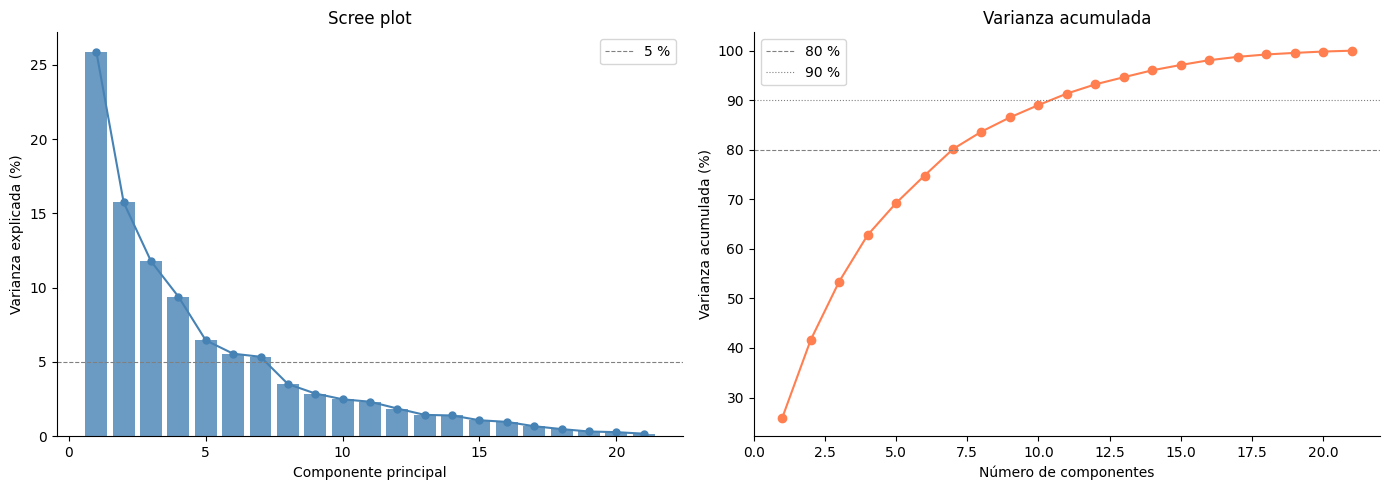

Componentes para 80 % de varianza: 7
Componentes para 90 % de varianza: 11

  PC1: 25.9 %  (acum. 25.9 %)
  PC2: 15.7 %  (acum. 41.6 %)
  PC3: 11.8 %  (acum. 53.4 %)
  PC4: 9.4 %  (acum. 62.8 %)
  PC5: 6.5 %  (acum. 69.2 %)
  PC6: 5.6 %  (acum. 74.8 %)


In [8]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp * 100, color="steelblue", alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp * 100, "o-", color="steelblue", ms=5)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree plot")
axes[0].axhline(5, color="gray", ls="--", lw=0.8, label="5 %")
axes[0].legend()

# Varianza acumulada
axes[1].plot(range(1, len(var_acum)+1), var_acum * 100, "o-", color="coral")
axes[1].axhline(80, color="gray", ls="--", lw=0.8, label="80 %")
axes[1].axhline(90, color="gray", ls=":", lw=0.8, label="90 %")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

n80 = int(np.argmax(var_acum >= 0.80)) + 1
n90 = int(np.argmax(var_acum >= 0.90)) + 1
print(f"Componentes para 80 % de varianza: {n80}")
print(f"Componentes para 90 % de varianza: {n90}")
print()
for i in range(min(6, len(var_exp))):
    print(f"  PC{i+1}: {var_exp[i]*100:.1f} %  (acum. {var_acum[i]*100:.1f} %)")

### 3.2 Biplot PC1 vs PC2 — bancos coloreados por tipo de entidad

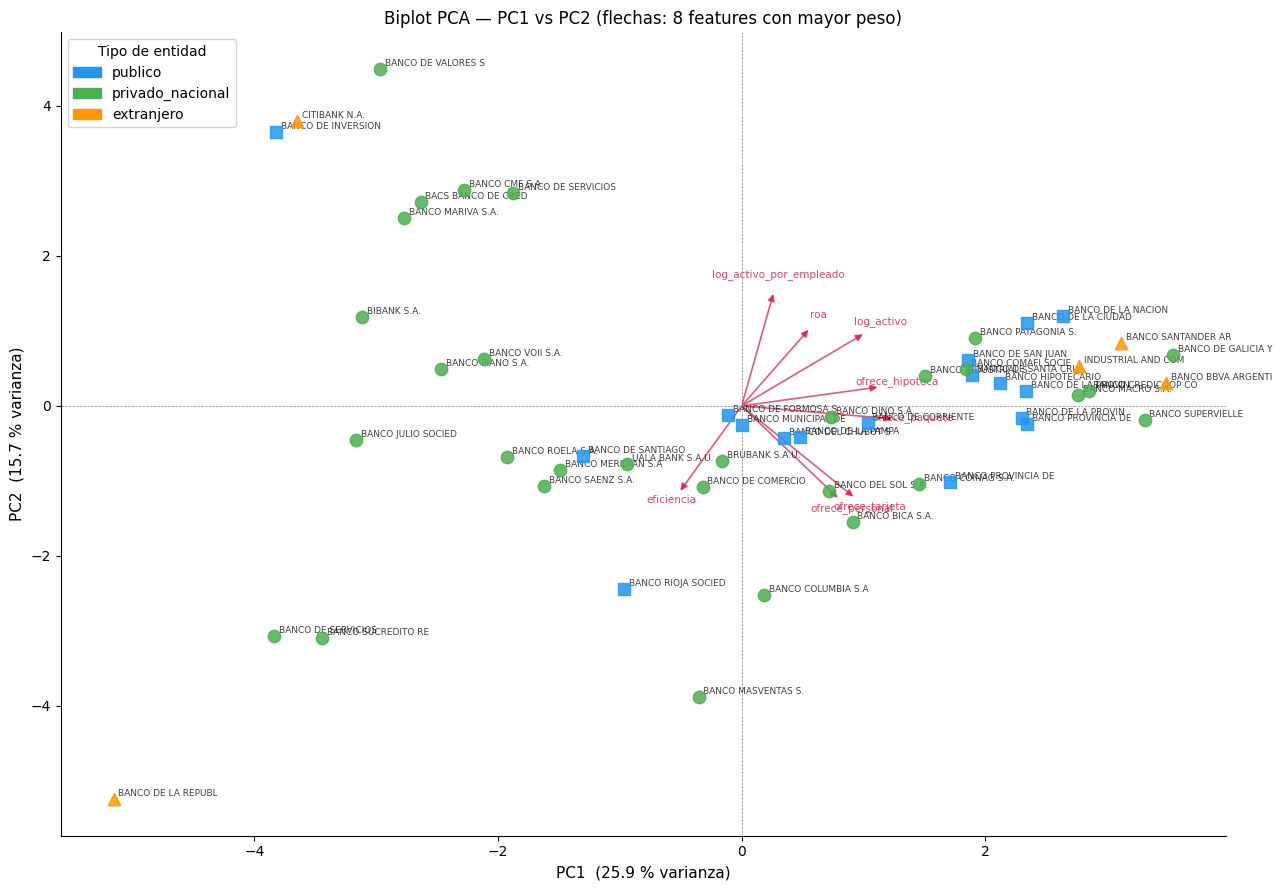

In [9]:
X_pca = pca_full.transform(X)

COLORES_TIPO = {
    "publico"         : "#2196F3",
    "privado_nacional": "#4CAF50",
    "extranjero"      : "#FF9800",
}
MARKERS_TIPO = {"publico": "s", "privado_nacional": "o", "extranjero": "^"}

fig, ax = plt.subplots(figsize=(13, 9))

for idx, row in df_imp.iterrows():
    tipo = row["tipo_entidad"]
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=COLORES_TIPO[tipo], marker=MARKERS_TIPO[tipo],
               s=80, alpha=0.85, zorder=5)
    nombre_corto = row["nombre_banco"][:18]
    ax.annotate(nombre_corto,
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

# Loadings arrows (solo las 8 con mayor magnitud en PC1 o PC2)
loadings = pca_full.components_[:2].T
magnitud = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_idx = np.argsort(magnitud)[-8:]
escala = 3.5
for j in top_idx:
    ax.annotate("", xy=(loadings[j, 0]*escala, loadings[j, 1]*escala), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="crimson", lw=1.2, alpha=0.7))
    ax.text(loadings[j, 0]*escala*1.12, loadings[j, 1]*escala*1.12,
            FEATURES[j], fontsize=7.5, color="crimson", alpha=0.8, ha="center")

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} % varianza)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} % varianza)", fontsize=11)
ax.set_title("Biplot PCA — PC1 vs PC2 (flechas: 8 features con mayor peso)", fontsize=12)

patches = [mpatches.Patch(color=COLORES_TIPO[t], label=t) for t in COLORES_TIPO]
ax.legend(handles=patches, title="Tipo de entidad", loc="upper left")

plt.tight_layout()
plt.show()

### 3.3 Loadings — ¿qué mide cada componente?

In [10]:
loadings_df = pd.DataFrame(
    pca_full.components_[:5].T,
    index=FEATURES,
    columns=[f"PC{i+1}" for i in range(5)]
)

print("Top 5 features por componente (valor absoluto del loading):\n")
for pc in loadings_df.columns:
    pct = var_exp[int(pc[2:])-1] * 100
    top = loadings_df[pc].abs().sort_values(ascending=False).head(5)
    print(f"  {pc}  ({pct:.1f} % varianza):")
    for feat, val in top.items():
        signo = "+" if loadings_df.loc[feat, pc] > 0 else "-"
        print(f"    {signo}{val:.3f}  {feat}")
    print()

Top 5 features por componente (valor absoluto del loading):

  PC1  (25.9 % varianza):
    +0.359  ofrece_paquete
    +0.325  ofrece_hipoteca
    +0.323  hipoteca_uva
    +0.290  log_activo
    +0.287  paquete_tiene_premium

  PC2  (15.7 % varianza):
    +0.437  log_activo_por_empleado
    -0.357  ofrece_personal
    -0.352  ofrece_tarjeta
    -0.332  eficiencia
    -0.306  cartera_irregular

  PC3  (11.8 % varianza):
    +0.527  liquidez
    +0.504  prestamos_sobre_activo
    -0.355  ofrece_pfijo
    +0.305  cartera_irregular
    -0.277  depositos_sobre_activo

  PC4  (9.4 % varianza):
    +0.508  patrimonio_sobre_activo
    +0.491  titulos_sobre_activo
    -0.369  depositos_sobre_activo
    +0.298  caja_apertura_simplificada
    +0.291  roa

  PC5  (6.5 % varianza):
    +0.470  tarjeta_tiene_premium
    -0.402  hipoteca_uva
    -0.390  ofrece_hipoteca
    -0.337  titulos_sobre_activo
    +0.283  roa



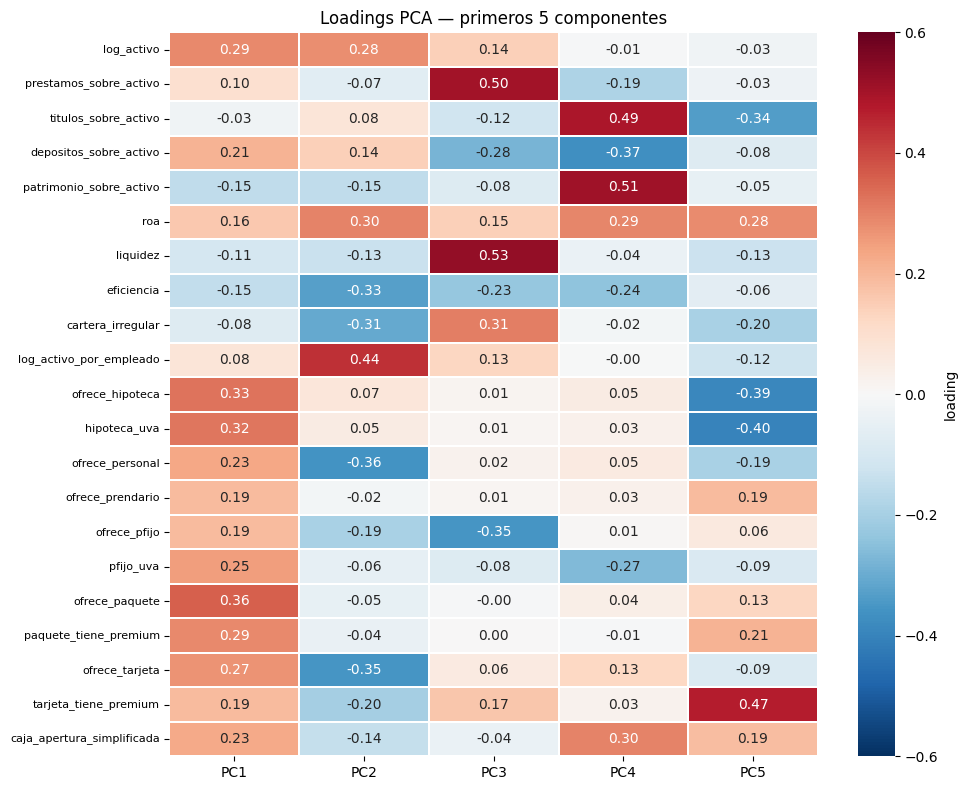

In [11]:
# Heatmap completo de loadings — primeros 5 PCs
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    loadings_df,
    cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
    annot=True, fmt=".2f", linewidths=0.3,
    ax=ax, cbar_kws={"label": "loading"}
)
ax.set_title("Loadings PCA — primeros 5 componentes", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## 4. K-Means

K-Means se corre sobre el **espacio completo estandarizado** (21 features, X), no sobre los scores PCA.
Los resultados se visualizan proyectados en el plano PC1-PC2.

### 4.1 Selección de k — Elbow + Silhouette

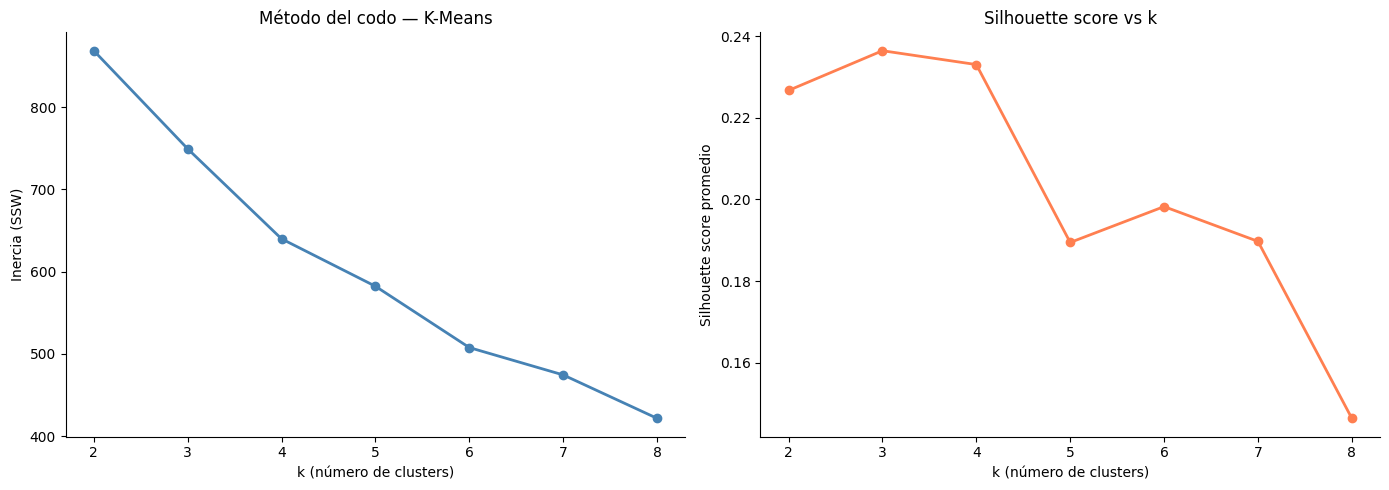

k con mayor silhouette: 3  (score = 0.236)

  k=2: silhouette = 0.227
  k=3: silhouette = 0.236  ← óptimo
  k=4: silhouette = 0.233
  k=5: silhouette = 0.189
  k=6: silhouette = 0.198
  k=7: silhouette = 0.190
  k=8: silhouette = 0.146


In [12]:
K_RANGE = range(2, 9)
inercias = []
siluetas = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=30)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inercias, "o-", color="steelblue", lw=2)
axes[0].set_xlabel("k (número de clusters)")
axes[0].set_ylabel("Inercia (SSW)")
axes[0].set_title("Método del codo — K-Means")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(K_RANGE, siluetas, "o-", color="coral", lw=2)
axes[1].set_xlabel("k (número de clusters)")
axes[1].set_ylabel("Silhouette score promedio")
axes[1].set_title("Silhouette score vs k")
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

k_opt = list(K_RANGE)[np.argmax(siluetas)]
print(f"k con mayor silhouette: {k_opt}  (score = {max(siluetas):.3f})")
print()
for k, sil in zip(K_RANGE, siluetas):
    marker = "  ← óptimo" if k == k_opt else ""
    print(f"  k={k}: silhouette = {sil:.3f}{marker}")

### 4.2 Ajuste del modelo final

In [13]:
# Ajustar con k elegido por silhouette (se puede sobreescribir)
K_OPTIMO = k_opt

km_final = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init=100)
df_imp["cluster_km"] = km_final.fit_predict(X)

print(f"K-Means con k = {K_OPTIMO}")
print(f"Silhouette score : {silhouette_score(X, df_imp['cluster_km']):.3f}")
print()
print("Distribución de clusters:")
print(df_imp["cluster_km"].value_counts().sort_index().to_string())
print()
print("\nComposición por tipo de entidad:")
ct = pd.crosstab(df_imp["cluster_km"], df_imp["tipo_entidad"])
print(ct.to_string())

K-Means con k = 3
Silhouette score : 0.243

Distribución de clusters:
cluster_km
0    11
1    29
2    12


Composición por tipo de entidad:
tipo_entidad  extranjero  privado_nacional  publico
cluster_km                                         
0                      1                 9        1
1                      3                12       14
2                      1                 9        2


### 4.3 Visualización en espacio PCA

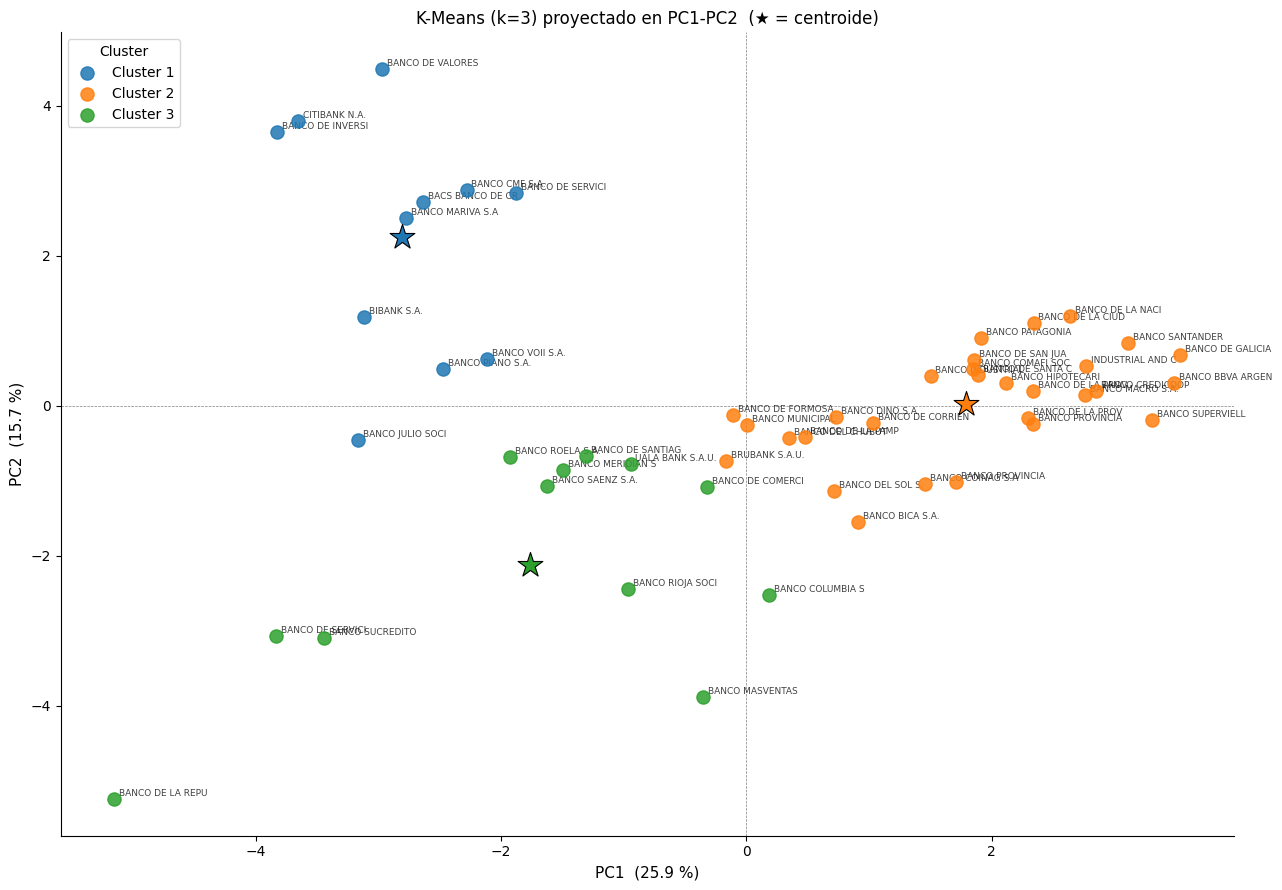

In [14]:
COLORES_KM = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(13, 9))

for cluster_id in sorted(df_imp["cluster_km"].unique()):
    mask = df_imp["cluster_km"] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[COLORES_KM[cluster_id]], label=f"Cluster {cluster_id + 1}",
               s=90, alpha=0.85, zorder=5)

for idx, row in df_imp.iterrows():
    ax.annotate(row["nombre_banco"][:16],
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

# Centroides proyectados en PCA
centroids_pca = pca_full.transform(km_final.cluster_centers_)
for i in range(K_OPTIMO):
    ax.scatter(centroids_pca[i, 0], centroids_pca[i, 1],
               marker="*", s=350, c=[COLORES_KM[i]],
               edgecolors="black", linewidths=0.8, zorder=10)

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} %)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} %)", fontsize=11)
ax.set_title(f"K-Means (k={K_OPTIMO}) proyectado en PC1-PC2  (★ = centroide)", fontsize=12)
ax.legend(title="Cluster", loc="upper left")

plt.tight_layout()
plt.show()

### 4.4 Perfil de clusters

In [15]:
# Mediana de las variables continuas por cluster
perfil_cont = df_imp.groupby("cluster_km")[FEATURES_CONTINUAS + ["n_productos_ofrecidos"]].median().round(3)
perfil_cont.index = [f"Cluster {i+1}" for i in perfil_cont.index]

print("Mediana por cluster — variables continuas:")
print(perfil_cont.T.to_string())

Mediana por cluster — variables continuas:
                         Cluster 1  Cluster 2  Cluster 3
log_activo                  19.666     21.325     18.339
prestamos_sobre_activo      22.200     33.164     22.068
titulos_sobre_activo         0.219      0.269      0.265
depositos_sobre_activo      54.573     67.080     46.714
patrimonio_sobre_activo      0.245      0.214      0.270
roa                          1.990      2.883     -1.376
liquidez                    20.492     20.449     25.561
eficiencia                  52.420     42.746     63.924
cartera_irregular            0.607      3.220      9.402
log_activo_por_empleado     14.738     14.135     13.411
n_productos_ofrecidos        1.000      5.000      3.000


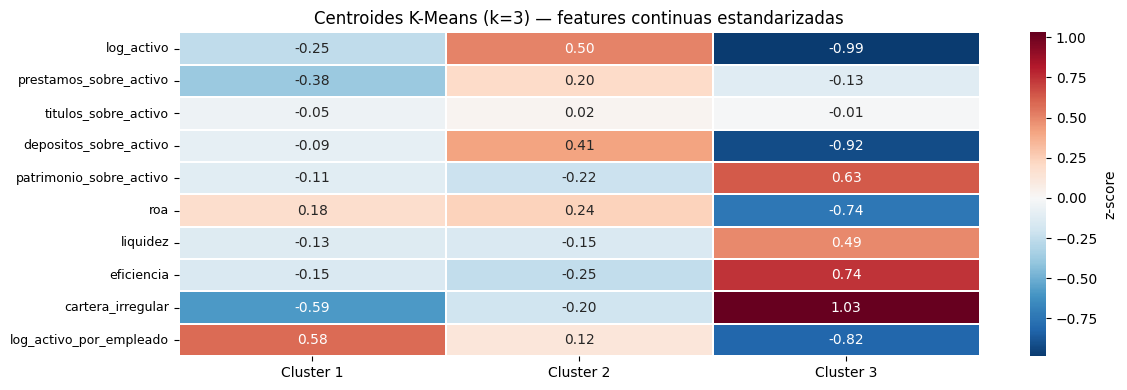

In [16]:
# Heatmap de centroides estandarizados (features continuas)
centroids_std = pd.DataFrame(
    km_final.cluster_centers_[:, :len(FEATURES_CONTINUAS)],
    columns=FEATURES_CONTINUAS,
    index=[f"Cluster {i+1}" for i in range(K_OPTIMO)]
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    centroids_std.T,
    cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", linewidths=0.3,
    ax=ax, cbar_kws={"label": "z-score"}
)
ax.set_title(f"Centroides K-Means (k={K_OPTIMO}) — features continuas estandarizadas", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

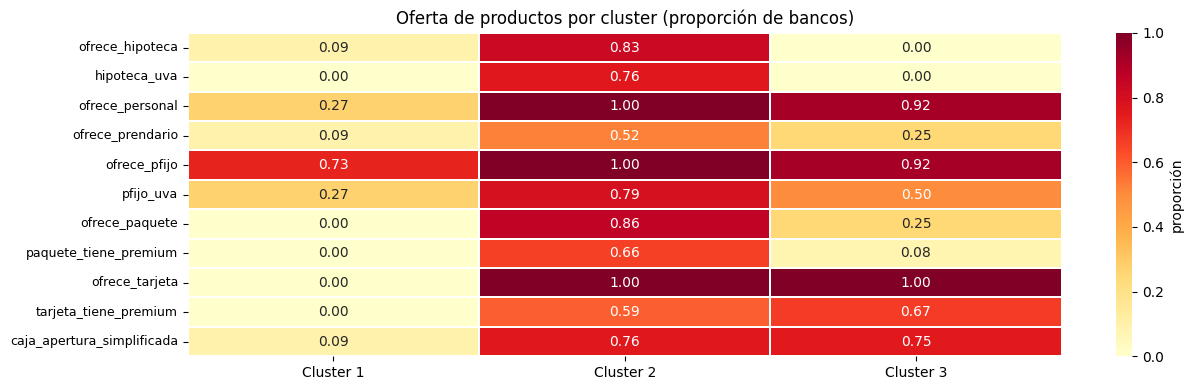

In [17]:
# Heatmap de oferta de productos por cluster (proporción de bancos que ofrecen)
perfil_bin = df_imp.groupby("cluster_km")[FEATURES_BINARIAS].mean().round(2)
perfil_bin.index = [f"Cluster {i+1}" for i in perfil_bin.index]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    perfil_bin.T,
    cmap="YlOrRd", vmin=0, vmax=1,
    annot=True, fmt=".2f", linewidths=0.3,
    ax=ax, cbar_kws={"label": "proporción"}
)
ax.set_title(f"Oferta de productos por cluster (proporción de bancos)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
# Lista de bancos por cluster
print("Bancos por cluster:\n")
for c in sorted(df_imp["cluster_km"].unique()):
    sub = df_imp[df_imp["cluster_km"] == c].sort_values("tipo_entidad")
    print(f"{'='*60}")
    print(f"CLUSTER {c+1}  ({len(sub)} bancos)")
    print(f"{'='*60}")
    for _, row in sub.iterrows():
        print(f"  [{row['tipo_entidad'][:3].upper()}]  {row['nombre_banco']}")
    print()

Bancos por cluster:

CLUSTER 1  (11 bancos)
  [EXT]  CITIBANK N.A.
  [PRI]  BIBANK S.A.
  [PRI]  BANCO DE VALORES S.A.
  [PRI]  BANCO MARIVA S.A.
  [PRI]  BANCO PIANO S.A.
  [PRI]  BANCO JULIO SOCIEDAD ANONIMA
  [PRI]  BANCO VOII S.A.
  [PRI]  BANCO CMF S.A.
  [PRI]  BANCO DE SERVICIOS Y TRANSACCIONES
  [PRI]  BACS BANCO DE CREDITO Y SECURITIZAC
  [PUB]  BANCO DE INVERSION Y COMERCIO EXTER

CLUSTER 2  (29 bancos)
  [EXT]  INDUSTRIAL AND COMMERCIAL BANK OF C
  [EXT]  BANCO BBVA ARGENTINA S.A.
  [EXT]  BANCO SANTANDER ARGENTINA S.A.
  [PRI]  BANCO DE GALICIA Y BUENOS AIRES S.A
  [PRI]  BANCO BICA S.A.
  [PRI]  BANCO INDUSTRIAL S.A.
  [PRI]  BANCO DEL SOL S.A.
  [PRI]  BANCO COMAFI SOCIEDAD ANONIMA
  [PRI]  BANCO MACRO S.A.
  [PRI]  BANCO CREDICOOP COOPERATIVO LIMITAD
  [PRI]  BRUBANK S.A.U.
  [PRI]  BANCO COINAG S.A.
  [PRI]  BANCO DINO S.A.
  [PRI]  BANCO PATAGONIA S.A.
  [PRI]  BANCO SUPERVIELLE S.A.
  [PUB]  BANCO DEL CHUBUT S.A.
  [PUB]  BANCO DE SAN JUAN S.A.
  [PUB]  BANCO DE LA PA

## 5. DBSCAN

DBSCAN se aplica sobre el **espacio PCA reducido** (primeros `n80` componentes).
Esto mitiga la maldición de la dimensionalidad: las distancias euclídeas son más
informativas en pocas dimensiones que en 21.

**Ventaja de DBSCAN sobre K-Means:** detecta clusters de forma arbitraria y marca
outliers explícitamente (etiqueta -1), lo que es útil para identificar bancos con
perfil atípico.

### 5.1 Espacio reducido para DBSCAN

In [19]:
# Usar los componentes que explican ≥ 80 % de varianza
N_COMP_DBSCAN = n80
X_red = X_pca[:, :N_COMP_DBSCAN]

print(f"Dimensiones para DBSCAN: {X_red.shape}  ({N_COMP_DBSCAN} PCs, {var_acum[N_COMP_DBSCAN-1]*100:.1f}% varianza)")

Dimensiones para DBSCAN: (52, 7)  (7 PCs, 80.2% varianza)


### 5.2 Calibración de eps — gráfico de distancias k-NN

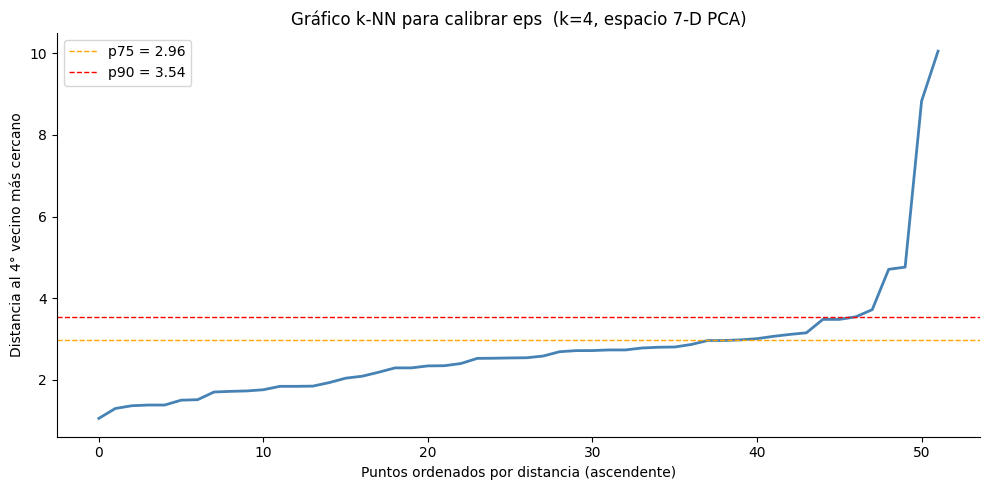

Percentiles de la distribución de distancias:
  p50: 2.536
  p60: 2.724
  p70: 2.845
  p75: 2.965
  p80: 3.052
  p85: 3.265
  p90: 3.535
  p95: 4.730


In [20]:
# El gráfico de distancias k-NN ayuda a elegir eps:
# eps = valor donde la curva hace "codo" (pasa de crecer lento a crecer rápido)
K_KNN = 4  # min_samples tentativo

knn = NearestNeighbors(n_neighbors=K_KNN)
knn.fit(X_red)
dists, _ = knn.kneighbors(X_red)
dists_k = np.sort(dists[:, -1])  # distancia al k-ésimo vecino, ordenada

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dists_k, color="steelblue", lw=2)
ax.set_xlabel("Puntos ordenados por distancia (ascendente)")
ax.set_ylabel(f"Distancia al {K_KNN}° vecino más cercano")
ax.set_title(f"Gráfico k-NN para calibrar eps  (k={K_KNN}, espacio {N_COMP_DBSCAN}-D PCA)")

# Percentiles de referencia
for p, col in [(75, "orange"), (90, "red")]:
    val = np.percentile(dists_k, p)
    ax.axhline(val, color=col, ls="--", lw=1, label=f"p{p} = {val:.2f}")

ax.legend()
plt.tight_layout()
plt.show()

print("Percentiles de la distribución de distancias:")
for p in [50, 60, 70, 75, 80, 85, 90, 95]:
    print(f"  p{p}: {np.percentile(dists_k, p):.3f}")

### 5.3 Ajuste de DBSCAN

Ajustar `EPS` y `MIN_SAMPLES` según el gráfico anterior.
Regla práctica: elegir eps en el "codo" de la curva k-NN.

In [21]:
# Ajustar según el gráfico de k-NN
# EPS = float(np.percentile(dists_k, 80))   # punto de inflexión orientativo
EPS = 1.5
MIN_SAMPLES = 3

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_imp["cluster_db"] = db.fit_predict(X_red)

n_clusters_db = len(set(df_imp["cluster_db"])) - (1 if -1 in df_imp["cluster_db"].values else 0)
n_ruido = (df_imp["cluster_db"] == -1).sum()

print(f"DBSCAN: eps={EPS:.3f}, min_samples={MIN_SAMPLES}")
print(f"Clusters encontrados : {n_clusters_db}")
print(f"Puntos de ruido      : {n_ruido} ({n_ruido/len(df_imp)*100:.1f} %)")
print()
print("Distribución:")
print(df_imp["cluster_db"].value_counts().sort_index().to_string())

DBSCAN: eps=1.500, min_samples=3
Clusters encontrados : 2
Puntos de ruido      : 44 (84.6 %)

Distribución:
cluster_db
-1    44
 0     4
 1     4


### 5.4 Visualización en espacio PCA

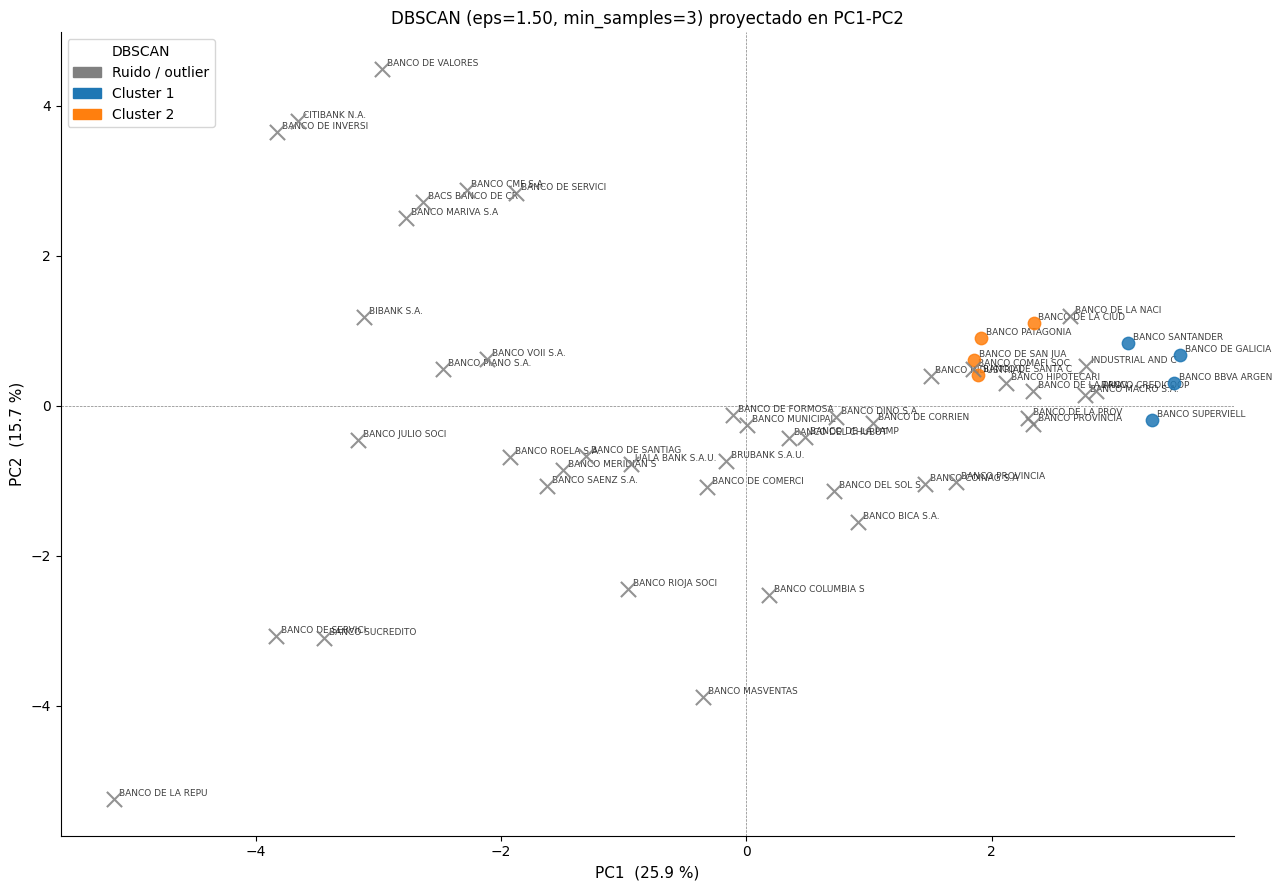


Bancos marcados como ruido/outliers:
                       nombre_banco     tipo_entidad
       BANCO DE LA NACION ARGENTINA          publico
BANCO DE LA PROVINCIA DE BUENOS AIR          publico
INDUSTRIAL AND COMMERCIAL BANK OF C       extranjero
                      CITIBANK N.A.       extranjero
BANCO DE LA PROVINCIA DE CORDOBA S.          publico
             BANCO HIPOTECARIO S.A.          publico
         BANCO MUNICIPAL DE ROSARIO          publico
              BANCO DEL CHUBUT S.A.          publico
               BANCO DE LA PAMPA SA          publico
           BANCO DE CORRIENTES S.A.          publico
BANCO PROVINCIA DEL NEUQUÉN SOCIEDA          publico
                     BRUBANK S.A.U. privado_nacional
                        BIBANK S.A. privado_nacional
BANCO CREDICOOP COOPERATIVO LIMITAD privado_nacional
              BANCO DE VALORES S.A. privado_nacional
                   BANCO ROELA S.A. privado_nacional
                  BANCO MARIVA S.A. privado_nacional
BANCO PR

In [22]:
unique_labels_db = sorted(df_imp["cluster_db"].unique())
palette_db = {}
color_idx = 0
for lab in unique_labels_db:
    if lab == -1:
        palette_db[lab] = ("gray", "x", 120, "Ruido / outlier")
    else:
        palette_db[lab] = (plt.cm.tab10.colors[color_idx], "o", 80, f"Cluster {lab+1}")
        color_idx += 1

fig, ax = plt.subplots(figsize=(13, 9))

for idx, row in df_imp.iterrows():
    lab = row["cluster_db"]
    color, marker, size, _ = palette_db[lab]
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=[color], marker=marker, s=size, alpha=0.85, zorder=5)
    ax.annotate(row["nombre_banco"][:16],
                (X_pca[idx, 0] + 0.04, X_pca[idx, 1] + 0.04),
                fontsize=6.5, alpha=0.75, zorder=4)

patches_db = [mpatches.Patch(color=v[0], label=v[3]) for v in palette_db.values()]
ax.legend(handles=patches_db, title="DBSCAN", loc="upper left")

ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f} %)", fontsize=11)
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f} %)", fontsize=11)
ax.set_title(f"DBSCAN (eps={EPS:.2f}, min_samples={MIN_SAMPLES}) proyectado en PC1-PC2", fontsize=12)

plt.tight_layout()
plt.show()

print("\nBancos marcados como ruido/outliers:")
outliers = df_imp[df_imp["cluster_db"] == -1][["nombre_banco", "tipo_entidad"]]
print(outliers.to_string(index=False) if len(outliers) > 0 else "  Ninguno")

### 5.5 Comparación K-Means vs DBSCAN

In [23]:
print("Tabla de contingencia: K-Means vs DBSCAN\n")
ct2 = pd.crosstab(
    df_imp["cluster_km"].map(lambda x: f"KM-{x+1}"),
    df_imp["cluster_db"].map(lambda x: f"DB-{x+1}" if x >= 0 else "Ruido"),
    rownames=["K-Means"], colnames=["DBSCAN"]
)
print(ct2.to_string())
print()

# Bancos con clasificación discordante entre algoritmos
# Para cada cluster de K-Means, la etiqueta DBSCAN más frecuente
mode_per_km = df_imp.groupby("cluster_km")["cluster_db"].agg(lambda x: x.mode().iloc[0])
df_imp["db_esperado"] = df_imp["cluster_km"].map(mode_per_km)
df_imp["coincide"] = df_imp["cluster_db"] == df_imp["db_esperado"]

discordantes = df_imp[~df_imp["coincide"]][["nombre_banco", "tipo_entidad", "cluster_km", "cluster_db"]].copy()
discordantes["cluster_km"] = discordantes["cluster_km"] + 1
print(f"Bancos con clasificación discordante entre algoritmos: {len(discordantes)}")
if len(discordantes) > 0:
    print(discordantes.to_string(index=False))

Tabla de contingencia: K-Means vs DBSCAN

DBSCAN   DB-1  DB-2  Ruido
K-Means                   
KM-1        0     0     11
KM-2        4     4     21
KM-3        0     0     12

Bancos con clasificación discordante entre algoritmos: 8
                       nombre_banco     tipo_entidad  cluster_km  cluster_db
BANCO DE GALICIA Y BUENOS AIRES S.A privado_nacional           2           0
          BANCO BBVA ARGENTINA S.A.       extranjero           2           0
             BANCO SUPERVIELLE S.A. privado_nacional           2           0
 BANCO DE LA CIUDAD DE BUENOS AIRES          publico           2           1
               BANCO PATAGONIA S.A. privado_nacional           2           1
             BANCO DE SAN JUAN S.A.          publico           2           1
     BANCO SANTANDER ARGENTINA S.A.       extranjero           2           0
           BANCO DE SANTA CRUZ S.A.          publico           2           1


## 6. Interpretación y conclusiones

In [24]:
# Tabla resumen comparativa por cluster K-Means
VARS_RESUMEN = {
    "log_activo"            : "Tamaño (log activo)",
    "roa"                   : "ROA (%)",
    "cartera_irregular"     : "Cartera irregular (%)",
    "liquidez"              : "Liquidez (%)",
    "eficiencia"            : "Eficiencia (%)",
    "prestamos_sobre_activo": "Préstamos / Activo (%)",
    "titulos_sobre_activo"  : "Títulos públicos / Activo (%)",
    "depositos_sobre_activo": "Depósitos / Activo (%)",
    "n_productos_ofrecidos" : "N° productos ofrecidos",
}

cols_resumen = list(VARS_RESUMEN.keys())
perfil_resumen = df_imp.groupby("cluster_km")[cols_resumen].median().round(3)
perfil_resumen.index = [f"Cluster {i+1}" for i in perfil_resumen.index]
perfil_resumen.columns = list(VARS_RESUMEN.values())

print("PERFIL DE CLUSTERS — K-Means (mediana)\n")
print(perfil_resumen.T.to_string())

PERFIL DE CLUSTERS — K-Means (mediana)

                               Cluster 1  Cluster 2  Cluster 3
Tamaño (log activo)               19.666     21.325     18.339
ROA (%)                            1.990      2.883     -1.376
Cartera irregular (%)              0.607      3.220      9.402
Liquidez (%)                      20.492     20.449     25.561
Eficiencia (%)                    52.420     42.746     63.924
Préstamos / Activo (%)            22.200     33.164     22.068
Títulos públicos / Activo (%)      0.219      0.269      0.265
Depósitos / Activo (%)            54.573     67.080     46.714
N° productos ofrecidos             1.000      5.000      3.000


In [25]:
# Composición por tipo de entidad
print("COMPOSICIÓN POR TIPO DE ENTIDAD\n")
comp = pd.crosstab(
    df_imp["cluster_km"].map(lambda x: f"Cluster {x+1}"),
    df_imp["tipo_entidad"],
    margins=True, margins_name="Total"
)
print(comp.to_string())

COMPOSICIÓN POR TIPO DE ENTIDAD

tipo_entidad  extranjero  privado_nacional  publico  Total
cluster_km                                                
Cluster 1              1                 9        1     11
Cluster 2              3                12       14     29
Cluster 3              1                 9        2     12
Total                  5                30       17     52


### 6.1 Conclusiones

> **Completar después de correr el notebook con los resultados reales.**

Preguntas guía para redactar las conclusiones:

1. ¿Cuántos clusters encontró K-Means? ¿Se corresponden con los tipos de entidad o hay subgrupos dentro de cada tipo?
2. ¿Qué variables pesan más en PC1 y PC2? ¿El eje de tamaño (`log_activo`) o el de rentabilidad (`roa`) domina?
3. ¿Coinciden K-Means y DBSCAN en la partición? ¿Qué bancos son robustamente outliers?
4. ¿Los clusters tienen interpretación de negocio clara? (ej.: banca mayorista, banca minorista masiva, banca pública, banca digital)
5. ¿Se justifica la exclusión de los 4 bancos mayoristas? ¿Hubieran dominado el espacio PCA de haberse incluido?